In [32]:
%pip install pandas sqlalchemy ipython-sql jupysql matplotlib
%pip install "prettytable>=3.12.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 39.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 39.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Basic Demo: One-Day Sari-Sari Store Sales Calculator

This notebook demonstrates the Basic goal of the Sari-Sari Store Simulator.

The Basic goal is to:

- Load one day of transactions
- Load inventory data
- Calculate revenue
- Calculate expenses
- Calculate gross profit
- Track remaining stock
- Create a ledger summary
- Save results to CSV
- Save results to SQLite
- Inspect results using SQL Magic

## 1. Set up project paths

Because this notebook is inside the `notebooks/` folder, we need to point Python back to the project root so it can import modules from `src/`.

In [2]:
from pathlib import Path
import sys

# The notebook is inside LT6_Final_Project/notebooks/
# Therefore, the project root is one folder above the current notebook folder.
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path so imports like src.basic.sales_calculator work.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project


In [3]:
# Define important project paths

INVENTORY_PATH = PROJECT_ROOT / "data/raw/inventory.csv"
TRANSACTIONS_PATH = PROJECT_ROOT / "data/raw/transactions.csv"

OUTPUT_FOLDER = PROJECT_ROOT / "data/processed/basic"
DATABASE_PATH = PROJECT_ROOT / "src/database/sari_sari_store.db"

print("Inventory path:", INVENTORY_PATH)
print("Transactions path:", TRANSACTIONS_PATH)
print("Output folder:", OUTPUT_FOLDER)
print("Database path:", DATABASE_PATH)

Inventory path: /Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/data/raw/inventory.csv
Transactions path: /Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/data/raw/transactions.csv
Output folder: /Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/data/processed/basic
Database path: /Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/src/database/sari_sari_store.db


In [4]:
# Check that required input files exist

print("inventory.csv exists:", INVENTORY_PATH.exists())
print("transactions.csv exists:", TRANSACTIONS_PATH.exists())

if not INVENTORY_PATH.exists():
    raise FileNotFoundError(f"Missing file: {INVENTORY_PATH}")

if not TRANSACTIONS_PATH.exists():
    raise FileNotFoundError(f"Missing file: {TRANSACTIONS_PATH}")

inventory.csv exists: True
transactions.csv exists: True


## 2. Preview raw input CSV files

The Basic version uses two CSV files:

1. `inventory.csv` — product-level stock, cost, and price data
2. `transactions.csv` — one day of sales transactions

In [5]:
import pandas as pd

inventory_raw = pd.read_csv(INVENTORY_PATH)
transactions_raw = pd.read_csv(TRANSACTIONS_PATH)

display(inventory_raw.head())
display(transactions_raw.head())

,product_id,product_name,category,starting_stock,unit_cost,unit_price
0,P001,Coke 1L,Beverage,24,60,75
1,P002,Royal 1L,Beverage,18,58,72
2,P003,Bottled Water 500ml,Beverage,30,10,15
3,P004,Piattos Snack,Snack,36,14,18
4,P005,Nova Snack,Snack,32,13,18


,transaction_id,transaction_date,product_id,quantity_sold
0,T001,2026-01-01,P001,2
1,T002,2026-01-01,P004,3
2,T003,2026-01-01,P012,5
3,T004,2026-01-01,P010,6
4,T005,2026-01-01,P006,2


In [6]:
print("Inventory shape:", inventory_raw.shape)
print("Transactions shape:", transactions_raw.shape)

print("\nInventory columns:")
print(list(inventory_raw.columns))

print("\nTransactions columns:")
print(list(transactions_raw.columns))

Inventory shape: (15, 6)
Transactions shape: (40, 4)

Inventory columns:
['product_id', 'product_name', 'category', 'starting_stock', 'unit_cost', 'unit_price']

Transactions columns:
['transaction_id', 'transaction_date', 'product_id', 'quantity_sold']


## 3. Load and validate the CSV files

Now we use the Basic data loader functions from `src/basic/data_loader.py`.

These functions validate:

- Required columns
- Missing values
- Invalid dates
- Invalid numeric values
- Duplicate product IDs
- Duplicate transaction IDs
- Product IDs in transactions that are missing from inventory

In [7]:
from src.basic.data_loader import (
    load_inventory,
    load_transactions,
    validate_transactions_match_inventory,
)

inventory = load_inventory(INVENTORY_PATH)
transactions = load_transactions(TRANSACTIONS_PATH)

validate_transactions_match_inventory(
    transactions=transactions,
    inventory=inventory,
)

print("Data loaded and validated successfully.")

Data loaded and validated successfully.


In [8]:
display(inventory.head())
display(transactions.head())

,product_id,product_name,category,starting_stock,unit_cost,unit_price
0,P001,Coke 1L,Beverage,24,60,75
1,P002,Royal 1L,Beverage,18,58,72
2,P003,Bottled Water 500ml,Beverage,30,10,15
3,P004,Piattos Snack,Snack,36,14,18
4,P005,Nova Snack,Snack,32,13,18


,transaction_id,transaction_date,product_id,quantity_sold
0,T001,2026-01-01,P001,2
1,T002,2026-01-01,P004,3
2,T003,2026-01-01,P012,5
3,T004,2026-01-01,P010,6
4,T005,2026-01-01,P006,2


In [9]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_id      15 non-null     str  
 1   product_name    15 non-null     str  
 2   category        15 non-null     str  
 3   starting_stock  15 non-null     int64
 4   unit_cost       15 non-null     int64
 5   unit_price      15 non-null     int64
dtypes: int64(3), str(3)
memory usage: 852.0 bytes


In [10]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    40 non-null     str           
 1   transaction_date  40 non-null     datetime64[us]
 2   product_id        40 non-null     str           
 3   quantity_sold     40 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 1.4 KB


## 4. Run the Basic sales calculations step by step

The next cells show each major part of the calculation:

1. Join transactions with inventory
2. Calculate revenue, expenses, and gross profit
3. Summarize results by product
4. Create a daily ledger summary

In [11]:
from src.basic.sales_calculator import (
    create_sales_details,
    create_product_summary,
    create_ledger_summary,
    print_basic_report,
)

sales_details = create_sales_details(
    inventory=inventory,
    transactions=transactions,
)

display(sales_details.head())

,transaction_id,transaction_date,product_id,quantity_sold,product_name,category,starting_stock,unit_cost,unit_price,revenue,expense,gross_profit
0,T001,2026-01-01,P001,2,Coke 1L,Beverage,24,60,75,150,120,30
1,T002,2026-01-01,P004,3,Piattos Snack,Snack,36,14,18,54,42,12
2,T003,2026-01-01,P012,5,Coffee Sachet,Beverage,80,5,8,40,25,15
3,T004,2026-01-01,P010,6,Egg,Food,60,7,10,60,42,18
4,T005,2026-01-01,P006,2,Lucky Me Beef Noodles,Food,40,10,14,28,20,8


In [12]:
# Show selected transaction-level columns

display(
    sales_details[
        [
            "transaction_id",
            "transaction_date",
            "product_id",
            "product_name",
            "category",
            "quantity_sold",
            "unit_price",
            "unit_cost",
            "revenue",
            "expense",
            "gross_profit",
        ]
    ].head(10)
)

,transaction_id,transaction_date,product_id,product_name,category,quantity_sold,unit_price,unit_cost,revenue,expense,gross_profit
0,T001,2026-01-01,P001,Coke 1L,Beverage,2,75,60,150,120,30
1,T002,2026-01-01,P004,Piattos Snack,Snack,3,18,14,54,42,12
2,T003,2026-01-01,P012,Coffee Sachet,Beverage,5,8,5,40,25,15
3,T004,2026-01-01,P010,Egg,Food,6,10,7,60,42,18
4,T005,2026-01-01,P006,Lucky Me Beef Noodles,Food,2,14,10,28,20,8
5,T006,2026-01-01,P003,Bottled Water 500ml,Beverage,4,15,10,60,40,20
6,T007,2026-01-01,P014,Laundry Detergent Sachet,Household,3,8,5,24,15,9
7,T008,2026-01-01,P013,Shampoo Sachet,Personal Care,4,7,4,28,16,12
8,T009,2026-01-01,P007,Pancit Canton Chilimansi,Food,2,16,12,32,24,8
9,T010,2026-01-01,P008,Canned Sardines,Food,1,28,22,28,22,6


In [13]:
product_summary = create_product_summary(sales_details)

display(product_summary)

,product_id,product_name,category,starting_stock,unit_cost,unit_price,total_quantity_sold,total_revenue,total_expense,total_gross_profit,remaining_stock,stock_status
0,P001,Coke 1L,Beverage,24,60,75,5,375,300,75,19,OK
1,P002,Royal 1L,Beverage,18,58,72,3,216,174,42,15,OK
2,P003,Bottled Water 500ml,Beverage,30,10,15,12,180,120,60,18,OK
3,P004,Piattos Snack,Snack,36,14,18,9,162,126,36,27,OK
4,P005,Nova Snack,Snack,32,13,18,5,90,65,25,27,OK
5,P006,Lucky Me Beef Noodles,Food,40,10,14,9,126,90,36,31,OK
6,P007,Pancit Canton Chilimansi,Food,40,12,16,9,144,108,36,31,OK
7,P008,Canned Sardines,Food,25,22,28,3,84,66,18,22,OK
8,P009,Corned Beef Small,Food,20,32,42,3,126,96,30,17,OK
9,P010,Egg,Food,60,7,10,24,240,168,72,36,OK


In [14]:
ledger_summary = create_ledger_summary(
    sales_details=sales_details,
    product_summary=product_summary,
)

display(ledger_summary)

,transaction_date,number_of_transactions,unique_products_sold,total_quantity_sold,total_revenue,total_expense,gross_profit,insufficient_stock_products,ledger_status
0,2026-01-01,40,15,137,2307,1692,615,0,BALANCED


In [15]:
print_basic_report(
    ledger_summary=ledger_summary,
    product_summary=product_summary,
)


BASIC GOAL: ONE-DAY SARI-SARI STORE SALES CALCULATOR
Transaction Date             : 2026-01-01
Number of Transactions       : 40
Unique Products Sold         : 15
Total Quantity Sold          : 137
Total Revenue                : PHP 2,307.00
Total Expenses               : PHP 1,692.00
Gross Profit                 : PHP 615.00
Insufficient Stock Products  : 0
Ledger Status                : BALANCED

PRODUCT SUMMARY
------------------------------------------------------------------------
product_id              product_name      category  starting_stock  unit_cost  unit_price  total_quantity_sold  total_revenue  total_expense  total_gross_profit  remaining_stock stock_status
      P001                   Coke 1L      Beverage              24         60          75                    5            375            300                  75               19           OK
      P002                  Royal 1L      Beverage              18         58          72                    3            216 

## 5. Run the full Basic workflow

The full workflow function performs all the same steps automatically and saves outputs to:

- `data/processed/basic/`
- `src/database/sari_sari_store.db`

In [16]:
from src.basic.sales_calculator import run_basic_sales_calculator

sales_details, product_summary, ledger_summary = run_basic_sales_calculator(
    inventory_csv_path=INVENTORY_PATH,
    transactions_csv_path=TRANSACTIONS_PATH,
    output_folder=OUTPUT_FOLDER,
    sqlite_db_path=DATABASE_PATH,
    save_csv_outputs=True,
    save_sqlite_database=True,
)


BASIC GOAL: ONE-DAY SARI-SARI STORE SALES CALCULATOR
Transaction Date             : 2026-01-01
Number of Transactions       : 40
Unique Products Sold         : 15
Total Quantity Sold          : 137
Total Revenue                : PHP 2,307.00
Total Expenses               : PHP 1,692.00
Gross Profit                 : PHP 615.00
Insufficient Stock Products  : 0
Ledger Status                : BALANCED

PRODUCT SUMMARY
------------------------------------------------------------------------
product_id              product_name      category  starting_stock  unit_cost  unit_price  total_quantity_sold  total_revenue  total_expense  total_gross_profit  remaining_stock stock_status
      P001                   Coke 1L      Beverage              24         60          75                    5            375            300                  75               19           OK
      P002                  Royal 1L      Beverage              18         58          72                    3            216 

## 6. Check generated CSV output files

In [17]:
generated_files = [
    OUTPUT_FOLDER / "daily_transaction_details.csv",
    OUTPUT_FOLDER / "daily_product_summary.csv",
    OUTPUT_FOLDER / "daily_ledger_summary.csv",
]

for file_path in generated_files:
    print(file_path, "exists:", file_path.exists())

/Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/data/processed/basic/daily_transaction_details.csv exists: True
/Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/data/processed/basic/daily_product_summary.csv exists: True
/Users/jacoabat/Documents/MAIDA 2027/DSC512/Project GitHub/LT6_Final_Project/data/processed/basic/daily_ledger_summary.csv exists: True


In [18]:
daily_transaction_details_csv = pd.read_csv(
    OUTPUT_FOLDER / "daily_transaction_details.csv"
)

daily_product_summary_csv = pd.read_csv(
    OUTPUT_FOLDER / "daily_product_summary.csv"
)

daily_ledger_summary_csv = pd.read_csv(
    OUTPUT_FOLDER / "daily_ledger_summary.csv"
)

display(daily_transaction_details_csv.head())
display(daily_product_summary_csv)
display(daily_ledger_summary_csv)

,transaction_id,transaction_date,product_id,quantity_sold,product_name,category,starting_stock,unit_cost,unit_price,revenue,expense,gross_profit
0,T001,2026-01-01,P001,2,Coke 1L,Beverage,24,60,75,150,120,30
1,T002,2026-01-01,P004,3,Piattos Snack,Snack,36,14,18,54,42,12
2,T003,2026-01-01,P012,5,Coffee Sachet,Beverage,80,5,8,40,25,15
3,T004,2026-01-01,P010,6,Egg,Food,60,7,10,60,42,18
4,T005,2026-01-01,P006,2,Lucky Me Beef Noodles,Food,40,10,14,28,20,8


,product_id,product_name,category,starting_stock,unit_cost,unit_price,total_quantity_sold,total_revenue,total_expense,total_gross_profit,remaining_stock,stock_status
0,P001,Coke 1L,Beverage,24,60,75,5,375,300,75,19,OK
1,P002,Royal 1L,Beverage,18,58,72,3,216,174,42,15,OK
2,P003,Bottled Water 500ml,Beverage,30,10,15,12,180,120,60,18,OK
3,P004,Piattos Snack,Snack,36,14,18,9,162,126,36,27,OK
4,P005,Nova Snack,Snack,32,13,18,5,90,65,25,27,OK
5,P006,Lucky Me Beef Noodles,Food,40,10,14,9,126,90,36,31,OK
6,P007,Pancit Canton Chilimansi,Food,40,12,16,9,144,108,36,31,OK
7,P008,Canned Sardines,Food,25,22,28,3,84,66,18,22,OK
8,P009,Corned Beef Small,Food,20,32,42,3,126,96,30,17,OK
9,P010,Egg,Food,60,7,10,24,240,168,72,36,OK


,transaction_date,number_of_transactions,unique_products_sold,total_quantity_sold,total_revenue,total_expense,gross_profit,insufficient_stock_products,ledger_status
0,2026-01-01,40,15,137,2307,1692,615,0,BALANCED


## 7. Connect to SQLite using SQL Magic

The Python script saved the tables into this SQLite database:

`src/database/sari_sari_store.db`

Now we inspect the tables with SQL Magic.

In [19]:
%load_ext sql

In [20]:
# Connect SQL Magic to the SQLite database.
# Because this notebook is inside notebooks/, use ../ to go back to the project root.

%sql sqlite:///../src/database/sari_sari_store.db

In [21]:
%%sql

SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;

 * sqlite:///../src/database/sari_sari_store.db
Done.


name
daily_ledger_summary
daily_product_summary
daily_transaction_details
inventory
transactions


## 8. Inspect SQLite tables

In [22]:
%%sql

SELECT *
FROM inventory
LIMIT 10;

 * sqlite:///../src/database/sari_sari_store.db
Done.


product_id,product_name,category,starting_stock,unit_cost,unit_price
P001,Coke 1L,Beverage,24,60,75
P002,Royal 1L,Beverage,18,58,72
P003,Bottled Water 500ml,Beverage,30,10,15
P004,Piattos Snack,Snack,36,14,18
P005,Nova Snack,Snack,32,13,18
P006,Lucky Me Beef Noodles,Food,40,10,14
P007,Pancit Canton Chilimansi,Food,40,12,16
P008,Canned Sardines,Food,25,22,28
P009,Corned Beef Small,Food,20,32,42
P010,Egg,Food,60,7,10


In [23]:
%%sql

SELECT *
FROM transactions
LIMIT 10;

 * sqlite:///../src/database/sari_sari_store.db
Done.


transaction_id,transaction_date,product_id,quantity_sold
T001,2026-01-01 00:00:00.000000,P001,2
T002,2026-01-01 00:00:00.000000,P004,3
T003,2026-01-01 00:00:00.000000,P012,5
T004,2026-01-01 00:00:00.000000,P010,6
T005,2026-01-01 00:00:00.000000,P006,2
T006,2026-01-01 00:00:00.000000,P003,4
T007,2026-01-01 00:00:00.000000,P014,3
T008,2026-01-01 00:00:00.000000,P013,4
T009,2026-01-01 00:00:00.000000,P007,2
T010,2026-01-01 00:00:00.000000,P008,1


In [24]:
%%sql

SELECT *
FROM daily_transaction_details
LIMIT 10;

 * sqlite:///../src/database/sari_sari_store.db
Done.


transaction_id,transaction_date,product_id,quantity_sold,product_name,category,starting_stock,unit_cost,unit_price,revenue,expense,gross_profit
T001,2026-01-01 00:00:00.000000,P001,2,Coke 1L,Beverage,24,60,75,150,120,30
T002,2026-01-01 00:00:00.000000,P004,3,Piattos Snack,Snack,36,14,18,54,42,12
T003,2026-01-01 00:00:00.000000,P012,5,Coffee Sachet,Beverage,80,5,8,40,25,15
T004,2026-01-01 00:00:00.000000,P010,6,Egg,Food,60,7,10,60,42,18
T005,2026-01-01 00:00:00.000000,P006,2,Lucky Me Beef Noodles,Food,40,10,14,28,20,8
T006,2026-01-01 00:00:00.000000,P003,4,Bottled Water 500ml,Beverage,30,10,15,60,40,20
T007,2026-01-01 00:00:00.000000,P014,3,Laundry Detergent Sachet,Household,75,5,8,24,15,9
T008,2026-01-01 00:00:00.000000,P013,4,Shampoo Sachet,Personal Care,70,4,7,28,16,12
T009,2026-01-01 00:00:00.000000,P007,2,Pancit Canton Chilimansi,Food,40,12,16,32,24,8
T010,2026-01-01 00:00:00.000000,P008,1,Canned Sardines,Food,25,22,28,28,22,6


In [25]:
%%sql

SELECT *
FROM daily_product_summary
ORDER BY product_id;

 * sqlite:///../src/database/sari_sari_store.db
Done.


product_id,product_name,category,starting_stock,unit_cost,unit_price,total_quantity_sold,total_revenue,total_expense,total_gross_profit,remaining_stock,stock_status
P001,Coke 1L,Beverage,24,60,75,5,375,300,75,19,OK
P002,Royal 1L,Beverage,18,58,72,3,216,174,42,15,OK
P003,Bottled Water 500ml,Beverage,30,10,15,12,180,120,60,18,OK
P004,Piattos Snack,Snack,36,14,18,9,162,126,36,27,OK
P005,Nova Snack,Snack,32,13,18,5,90,65,25,27,OK
P006,Lucky Me Beef Noodles,Food,40,10,14,9,126,90,36,31,OK
P007,Pancit Canton Chilimansi,Food,40,12,16,9,144,108,36,31,OK
P008,Canned Sardines,Food,25,22,28,3,84,66,18,22,OK
P009,Corned Beef Small,Food,20,32,42,3,126,96,30,17,OK
P010,Egg,Food,60,7,10,24,240,168,72,36,OK


In [26]:
%%sql

SELECT *
FROM daily_ledger_summary;

 * sqlite:///../src/database/sari_sari_store.db
Done.


transaction_date,number_of_transactions,unique_products_sold,total_quantity_sold,total_revenue,total_expense,gross_profit,insufficient_stock_products,ledger_status
2026-01-01,40,15,137,2307,1692,615,0,BALANCED


## 9. SQL ledger check

This query recalculates total revenue, total expense, and gross profit directly from the base tables:

- `transactions`
- `inventory`

This verifies that the stored ledger matches the raw data.

In [27]:
%%sql

SELECT
    SUM(t.quantity_sold * i.unit_price) AS total_revenue,
    SUM(t.quantity_sold * i.unit_cost) AS total_expense,
    SUM(t.quantity_sold * i.unit_price) - SUM(t.quantity_sold * i.unit_cost) AS gross_profit
FROM transactions AS t
JOIN inventory AS i
    ON t.product_id = i.product_id;

 * sqlite:///../src/database/sari_sari_store.db
Done.


total_revenue,total_expense,gross_profit
2307,1692,615


## 10. SQL stock check

This query checks whether each product still has enough stock after the day's sales.

In [28]:
%%sql

SELECT
    i.product_id,
    i.product_name,
    i.category,
    i.starting_stock,
    COALESCE(SUM(t.quantity_sold), 0) AS total_quantity_sold,
    i.starting_stock - COALESCE(SUM(t.quantity_sold), 0) AS remaining_stock,
    CASE
        WHEN i.starting_stock - COALESCE(SUM(t.quantity_sold), 0) >= 0
            THEN 'OK'
        ELSE 'INSUFFICIENT STOCK'
    END AS stock_status
FROM inventory AS i
LEFT JOIN transactions AS t
    ON i.product_id = t.product_id
GROUP BY
    i.product_id,
    i.product_name,
    i.category,
    i.starting_stock
ORDER BY i.product_id;

 * sqlite:///../src/database/sari_sari_store.db
Done.


product_id,product_name,category,starting_stock,total_quantity_sold,remaining_stock,stock_status
P001,Coke 1L,Beverage,24,5,19,OK
P002,Royal 1L,Beverage,18,3,15,OK
P003,Bottled Water 500ml,Beverage,30,12,18,OK
P004,Piattos Snack,Snack,36,9,27,OK
P005,Nova Snack,Snack,32,5,27,OK
P006,Lucky Me Beef Noodles,Food,40,9,31,OK
P007,Pancit Canton Chilimansi,Food,40,9,31,OK
P008,Canned Sardines,Food,25,3,22,OK
P009,Corned Beef Small,Food,20,3,17,OK
P010,Egg,Food,60,24,36,OK


## 11. Product performance checks

In [29]:
%%sql

SELECT
    product_id,
    product_name,
    category,
    total_quantity_sold,
    total_revenue,
    total_expense,
    total_gross_profit,
    remaining_stock,
    stock_status
FROM daily_product_summary
ORDER BY total_revenue DESC;

 * sqlite:///../src/database/sari_sari_store.db
Done.


product_id,product_name,category,total_quantity_sold,total_revenue,total_expense,total_gross_profit,remaining_stock,stock_status
P001,Coke 1L,Beverage,5,375,300,75,19,OK
P010,Egg,Food,24,240,168,72,36,OK
P002,Royal 1L,Beverage,3,216,174,42,15,OK
P012,Coffee Sachet,Beverage,23,184,115,69,57,OK
P003,Bottled Water 500ml,Beverage,12,180,120,60,18,OK
P004,Piattos Snack,Snack,9,162,126,36,27,OK
P011,Rice 1kg,Food,3,150,126,24,27,OK
P007,Pancit Canton Chilimansi,Food,9,144,108,36,31,OK
P006,Lucky Me Beef Noodles,Food,9,126,90,36,31,OK
P009,Corned Beef Small,Food,3,126,96,30,17,OK


In [30]:
%%sql

SELECT
    category,
    SUM(total_quantity_sold) AS category_quantity_sold,
    SUM(total_revenue) AS category_revenue,
    SUM(total_expense) AS category_expense,
    SUM(total_gross_profit) AS category_gross_profit
FROM daily_product_summary
GROUP BY category
ORDER BY category_revenue DESC;

 * sqlite:///../src/database/sari_sari_store.db
Done.


category,category_quantity_sold,category_revenue,category_expense,category_gross_profit
Beverage,43,955,709,246
Food,51,870,654,216
Snack,14,252,191,61
Household,17,146,90,56
Personal Care,12,84,48,36


## 12. Simple visualizations

The next cells create basic charts from the product summary.

Matplotlib is building the font cache; this may take a moment.


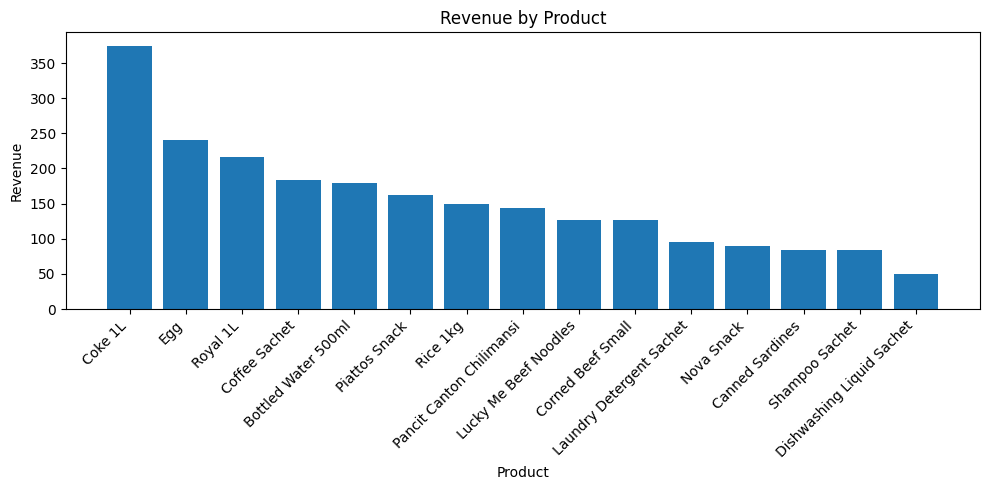

In [33]:
import matplotlib.pyplot as plt

product_summary_sorted = product_summary.sort_values(
    by="total_revenue",
    ascending=False,
)

plt.figure(figsize=(10, 5))
plt.bar(
    product_summary_sorted["product_name"],
    product_summary_sorted["total_revenue"],
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

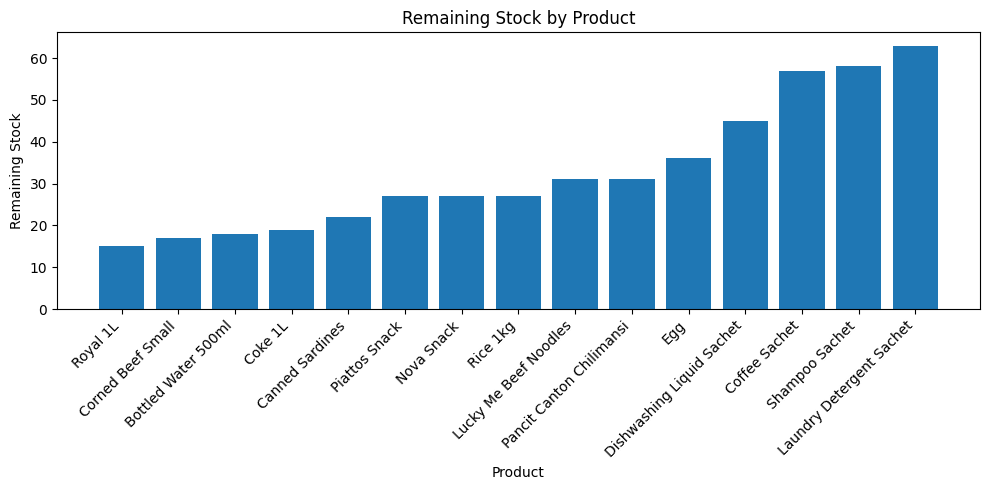

In [34]:
stock_summary_sorted = product_summary.sort_values(
    by="remaining_stock",
    ascending=True,
)

plt.figure(figsize=(10, 5))
plt.bar(
    stock_summary_sorted["product_name"],
    stock_summary_sorted["remaining_stock"],
)

plt.title("Remaining Stock by Product")
plt.xlabel("Product")
plt.ylabel("Remaining Stock")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
category_summary = (
    product_summary
    .groupby("category", as_index=False)
    .agg(
        category_revenue=("total_revenue", "sum"),
        category_expense=("total_expense", "sum"),
        category_gross_profit=("total_gross_profit", "sum"),
    )
)

display(category_summary)

,category,category_revenue,category_expense,category_gross_profit
0,Beverage,955,709,246
1,Food,870,654,216
2,Household,146,90,56
3,Personal Care,84,48,36
4,Snack,252,191,61


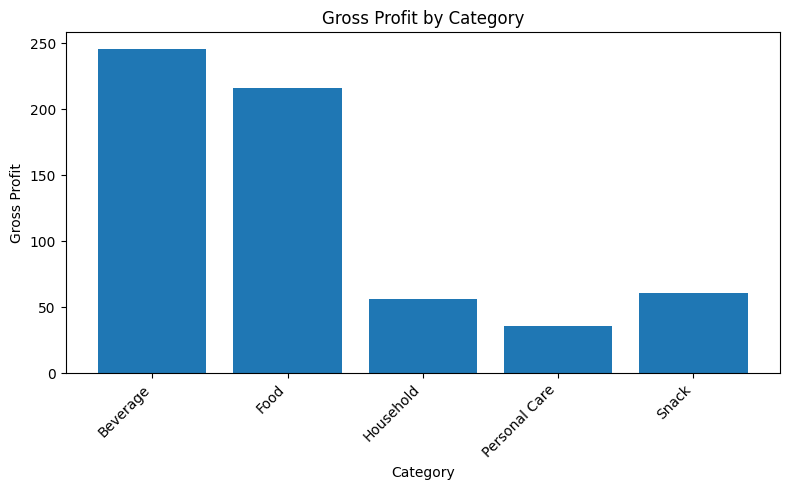

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(
    category_summary["category"],
    category_summary["category_gross_profit"],
)

plt.title("Gross Profit by Category")
plt.xlabel("Category")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Final Basic goal validation

The Basic goal is successful if:

- Revenue is calculated
- Expenses are calculated
- Gross profit is calculated
- Remaining stock is calculated
- No unexpected stock issues exist
- The ledger status is `BALANCED`
- Output CSV files are created
- SQLite tables are created

In [37]:
ledger_status = ledger_summary.loc[0, "ledger_status"]

print("Ledger status:", ledger_status)

if ledger_status == "BALANCED":
    print("Basic goal completed successfully.")
else:
    print("Basic goal needs review.")

Ledger status: BALANCED
Basic goal completed successfully.


In [38]:
# Final checklist

checks = {
    "inventory_loaded": not inventory.empty,
    "transactions_loaded": not transactions.empty,
    "sales_details_created": not sales_details.empty,
    "product_summary_created": not product_summary.empty,
    "ledger_summary_created": not ledger_summary.empty,
    "database_created": DATABASE_PATH.exists(),
    "transaction_details_csv_created": (OUTPUT_FOLDER / "daily_transaction_details.csv").exists(),
    "product_summary_csv_created": (OUTPUT_FOLDER / "daily_product_summary.csv").exists(),
    "ledger_summary_csv_created": (OUTPUT_FOLDER / "daily_ledger_summary.csv").exists(),
}

checks

{'inventory_loaded': True,
 'transactions_loaded': True,
 'sales_details_created': True,
 'product_summary_created': True,
 'ledger_summary_created': True,
 'database_created': True,
 'transaction_details_csv_created': True,
 'product_summary_csv_created': True,
 'ledger_summary_csv_created': True}

## End of Basic Demo

This notebook demonstrated the Basic level of the Sari-Sari Store Simulator.

The main project logic is stored in `.py` files under `src/basic/`.

This notebook is only used for demonstration, validation, SQL Magic inspection, and simple visualizations.